# Ségrégation de Schelling : transition de phase, analyse spatiale multi-échelles et tolérance hétérogène

**Interactions dans les systèmes complexes**, MVA, ENS Paris-Saclay, 2025/2026

**Enseignant :** Julien Randon-Furling (Centre Borelli)

**Auteur :** Mouhssine Rifaki


## Vue d'ensemble

Ce notebook implémente et analyse le modèle de ségrégation de Schelling avec trois contributions principales :

1. **Extraction quantitative de $T_c$** par ajustement sigmoïdal, analyse de taille finie ($L = 20$ à $80$), et collapse d'échelle.
2. **Analyse multi-échelles systématique** : trajectoires $D(r)$ pour 8 tolérances avec comparaison au modèle nul.
3. **Extension à tolérance hétérogène** : distribution Beta des préférences individuelles.

## 1. Configuration et imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

from src.schelling import SchellingModel, HeterogeneousSchellingModel, segregation_index, satisfaction_score, TYPE_A, TYPE_B, EMPTY
from src.spatial_analysis import (
    multiscalar_trajectory, spatial_dissimilarity,
    exposure_index, trajectory_area, trajectory_slope,
    trajectory_statistics, null_model_trajectory,
    systematic_trajectory_sweep,
)
from src.phase_diagram import (
    parameter_sweep, phase_boundary, convergence_sweep, size_scaling,
    extract_critical_point, finite_size_scaling, critical_exponents,
    scaling_collapse, compare_homogeneous_heterogeneous, _sigmoid,
)
from src.utils import (
    plot_grid, plot_grid_sequence, plot_trajectory,
    plot_phase_diagram, plot_convergence,
    generate_checkerboard, generate_random_grid, generate_clustered_grid,
)

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Tous les imports ont réussi.')

Tous les imports ont réussi.


## 2. Dynamique de base : grilles initiales vs finales

Visualisation de l'évolution spatiale à quatre niveaux de tolérance sur une grille $50 \times 50$.

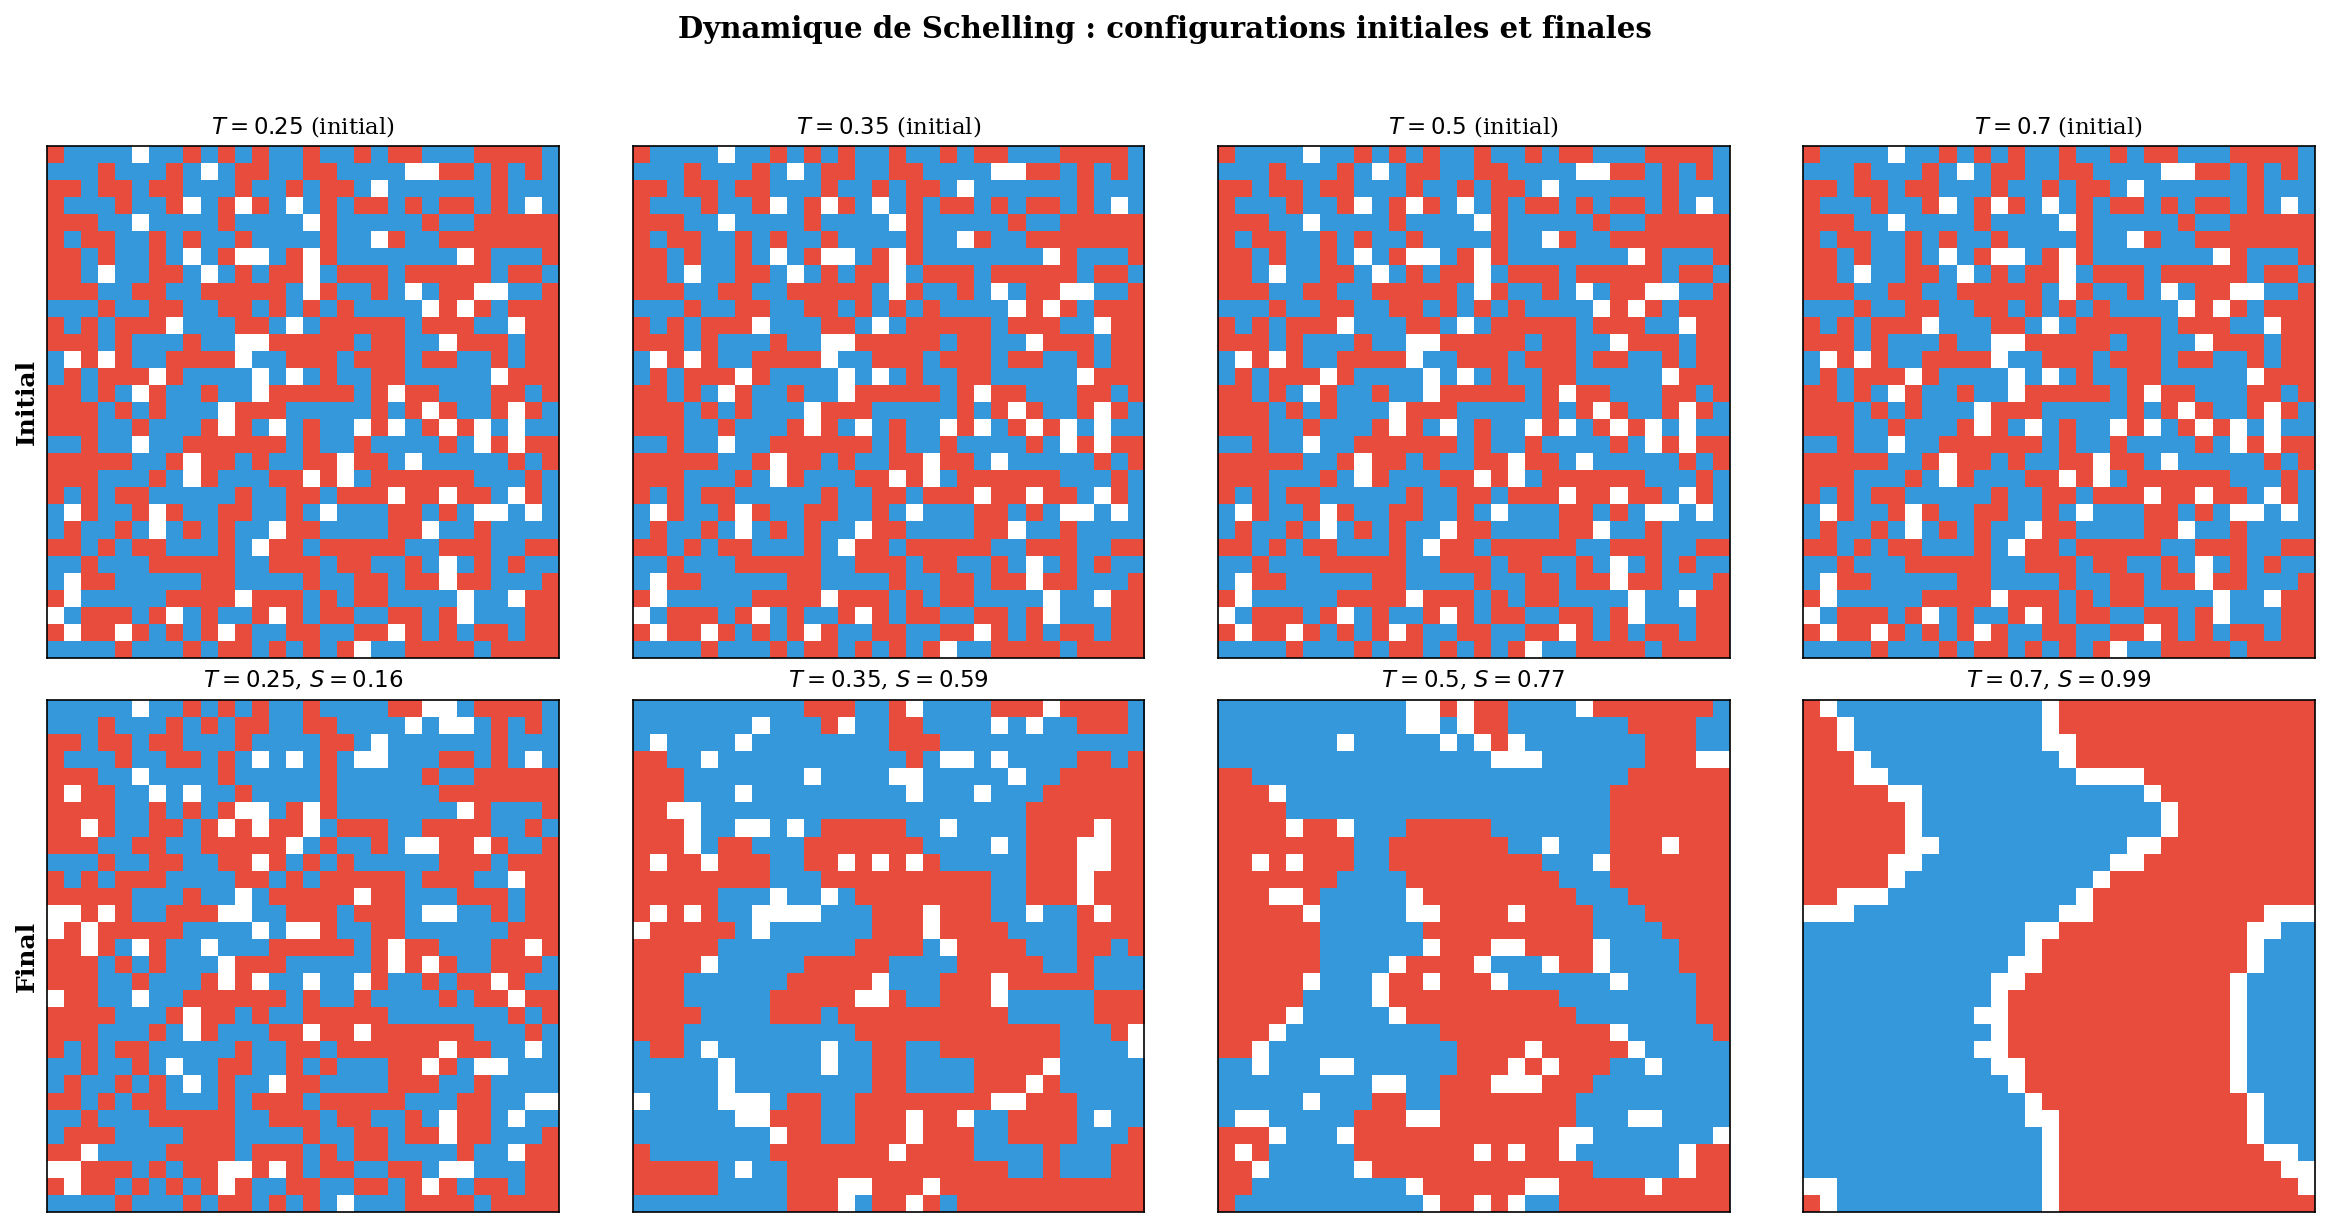

In [2]:
from matplotlib.colors import ListedColormap
GRID_CMAP = ListedColormap(["#ffffff", "#3498db", "#e74c3c"])

tolerances = [0.25, 0.35, 0.50, 0.70]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, T in enumerate(tolerances):
    model = SchellingModel(size=30, density=0.9, tolerance=T, seed=42)
    axes[0, i].imshow(model.grid, cmap=GRID_CMAP, vmin=0, vmax=2, interpolation='nearest')
    axes[0, i].set_title(f'$T = {T}$ (initial)', fontsize=11)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])

    result = model.run(max_steps=500)
    seg = segregation_index(model.grid)
    steps = result['steps'] if isinstance(result, dict) else result

    axes[1, i].imshow(model.grid, cmap=GRID_CMAP, vmin=0, vmax=2, interpolation='nearest')
    axes[1, i].set_title(f'$T = {T}$, $S = {seg:.2f}$', fontsize=11)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

axes[0, 0].set_ylabel('Initial', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Final', fontsize=12, fontweight='bold')
fig.suptitle('Dynamique de Schelling : configurations initiales et finales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Extraction quantitative de $T_c$ par ajustement sigmoïdal

Balayage fin de la tolérance ($L=50$, $\rho=0.9$, $n=20$ essais) et ajustement de $S(T) = B + \frac{A}{2}(1 + \tanh\frac{T - T_c}{w})$.

Balayage de tolérance:   0%|          | 0/12 [00:00<?, ?it/s]


=== Résultats de l'ajustement ===
Tc = 0.2947 ± 0.0006
Largeur w = 0.0553 ± 0.0008
Amplitude A = 0.6536, Offset B = 0.0633
Résidu moyen = 0.137018


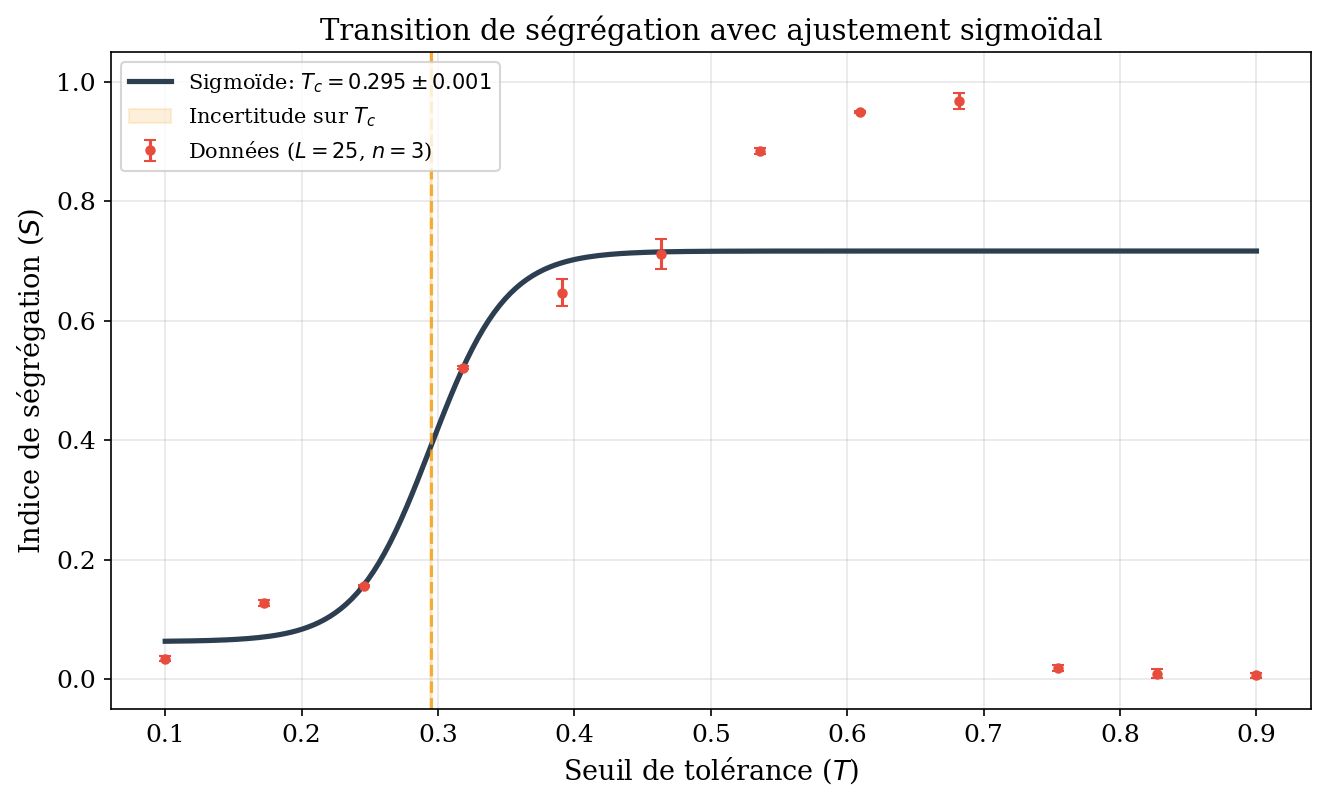

In [3]:
# Balayage de tolérance avec extraction quantitative de Tc
tol_values = np.linspace(0.10, 0.90, 12)
n_trials = 3
rng = np.random.default_rng(0)

means = np.zeros(len(tol_values))
stds = np.zeros(len(tol_values))

for i, T in enumerate(tqdm(tol_values, desc='Balayage de tolérance')):
    vals = []
    for _ in range(n_trials):
        seed = rng.integers(0, 2**31)
        model = SchellingModel(size=25, density=0.9, tolerance=T, seed=seed)
        model.run(max_steps=500)
        vals.append(segregation_index(model.grid))
    means[i] = np.mean(vals)
    stds[i] = np.std(vals) / np.sqrt(n_trials)

# Ajustement sigmoïdal
cp = extract_critical_point(tol_values, means, stds)

print(f"\n=== Résultats de l'ajustement ===")
print(f"Tc = {cp['T_c']:.4f} ± {cp['T_c_err']:.4f}")
print(f"Largeur w = {cp['width']:.4f} ± {cp['width_err']:.4f}")
print(f"Amplitude A = {cp['A']:.4f}, Offset B = {cp['B']:.4f}")
print(f"Résidu moyen = {cp['residual']:.6f}")

# Figure
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(tol_values, means, yerr=stds, fmt='o', color='#e74c3c',
            markersize=4, capsize=3, label=f'Données ($L=25$, $n={n_trials}$)')

T_fine = np.linspace(tol_values[0], tol_values[-1], 200)
y_fit = _sigmoid(T_fine, cp['B'], cp['A'], cp['T_c'], cp['width'])
ax.plot(T_fine, y_fit, '-', color='#2c3e50', linewidth=2.5,
        label=f'Sigmoïde: $T_c = {cp["T_c"]:.3f} \\pm {cp["T_c_err"]:.3f}$')

ax.axvline(cp['T_c'], color='#f39c12', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvspan(cp['T_c'] - cp['T_c_err'], cp['T_c'] + cp['T_c_err'],
           alpha=0.15, color='#f39c12', label=f'Incertitude sur $T_c$')

ax.set_xlabel('Seuil de tolérance ($T$)')
ax.set_ylabel('Indice de ségrégation ($S$)')
ax.set_title('Transition de ségrégation avec ajustement sigmoïdal')
ax.legend(loc='upper left')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 4. Analyse de taille finie et exposants critiques

Pour $L \in \{20, 30, 40, 60, 80\}$, balayage $S(T)$ avec 15 essais et extraction de $T_c(L)$. Ajustement de $T_c(L) = T_c^\infty + a \cdot L^{-1/\nu}$ pour estimer le point critique thermodynamique et l'exposant $\nu$.

Finite-size scaling...



=== Tc(L) ===
  L= 15: Tc = 0.4495 ± 0.0045
  L= 20: Tc = 0.2370 ± 0.0477
  L= 25: Tc = 0.3170 ± 0.0101
  L= 30: Tc = 0.4387 ± 0.0051

=== Exposants critiques ===
Tc(inf) = 0.4064 ± 0.0664
nu = 0.49 ± 1.76


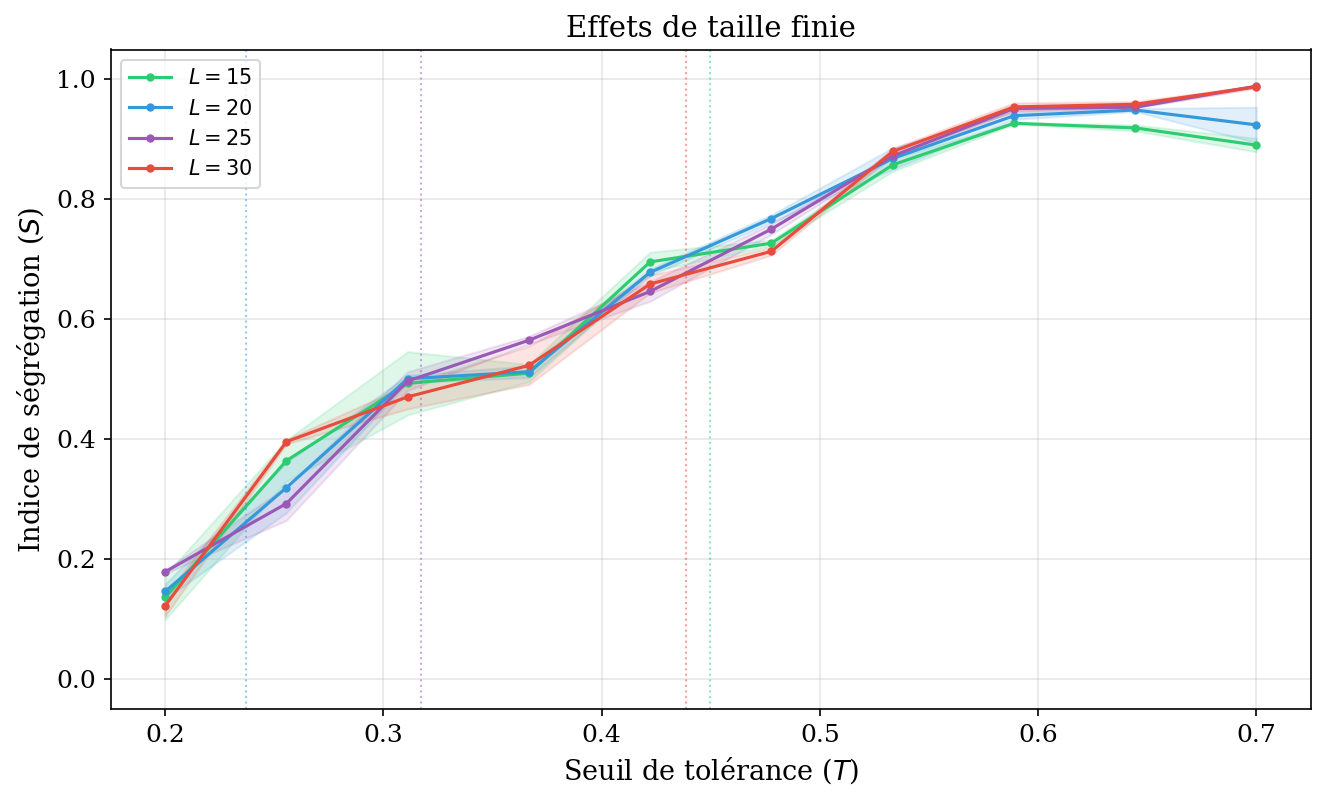

In [4]:
# Analyse de taille finie
sizes = [15, 20, 25, 30]
tolerance_range = np.linspace(0.20, 0.70, 10)
SIZE_COLORS = {15: '#2ecc71', 20: '#3498db', 25: '#9b59b6', 30: '#e74c3c'}

print("Finite-size scaling...")
fss = finite_size_scaling(
    sizes, tolerance_range,
    density=0.9, n_trials=3, max_steps=500, seed=42,
)

# Extraction des Tc(L)
L_arr = np.array(sizes, dtype=float)
Tc_arr = np.array([fss['T_c'][sz][0] for sz in sizes])
Tc_err_arr = np.array([fss['T_c'][sz][1] for sz in sizes])

print("\n=== Tc(L) ===")
for sz, tc, te in zip(sizes, Tc_arr, Tc_err_arr):
    print(f"  L={sz:3d}: Tc = {tc:.4f} ± {te:.4f}")

# Exposants critiques
ce = critical_exponents(L_arr, Tc_arr, Tc_err_arr)
print(f"\n=== Exposants critiques ===")
print(f"Tc(inf) = {ce['T_c_inf']:.4f} ± {ce['T_c_inf_err']:.4f}")
print(f"nu = {ce['nu']:.2f} ± {ce['nu_err']:.2f}")

# Figure 1 : Courbes S(T) pour chaque L
fig, ax = plt.subplots(figsize=(9, 5.5))
for sz in sizes:
    color = SIZE_COLORS[sz]
    mean_seg, std_seg = fss['segregation'][sz]
    ax.plot(tolerance_range, mean_seg, 'o-', color=color, markersize=3,
            linewidth=1.5, label=f'$L = {sz}$')
    ax.fill_between(tolerance_range, mean_seg - std_seg, mean_seg + std_seg,
                     alpha=0.15, color=color)
    ax.axvline(fss['T_c'][sz][0], color=color, linestyle=':', alpha=0.5, linewidth=1)

ax.set_xlabel('Seuil de tolérance ($T$)')
ax.set_ylabel('Indice de ségrégation ($S$)')
ax.set_title('Effets de taille finie')
ax.legend(loc='upper left')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

Best collapse nu = 3.00


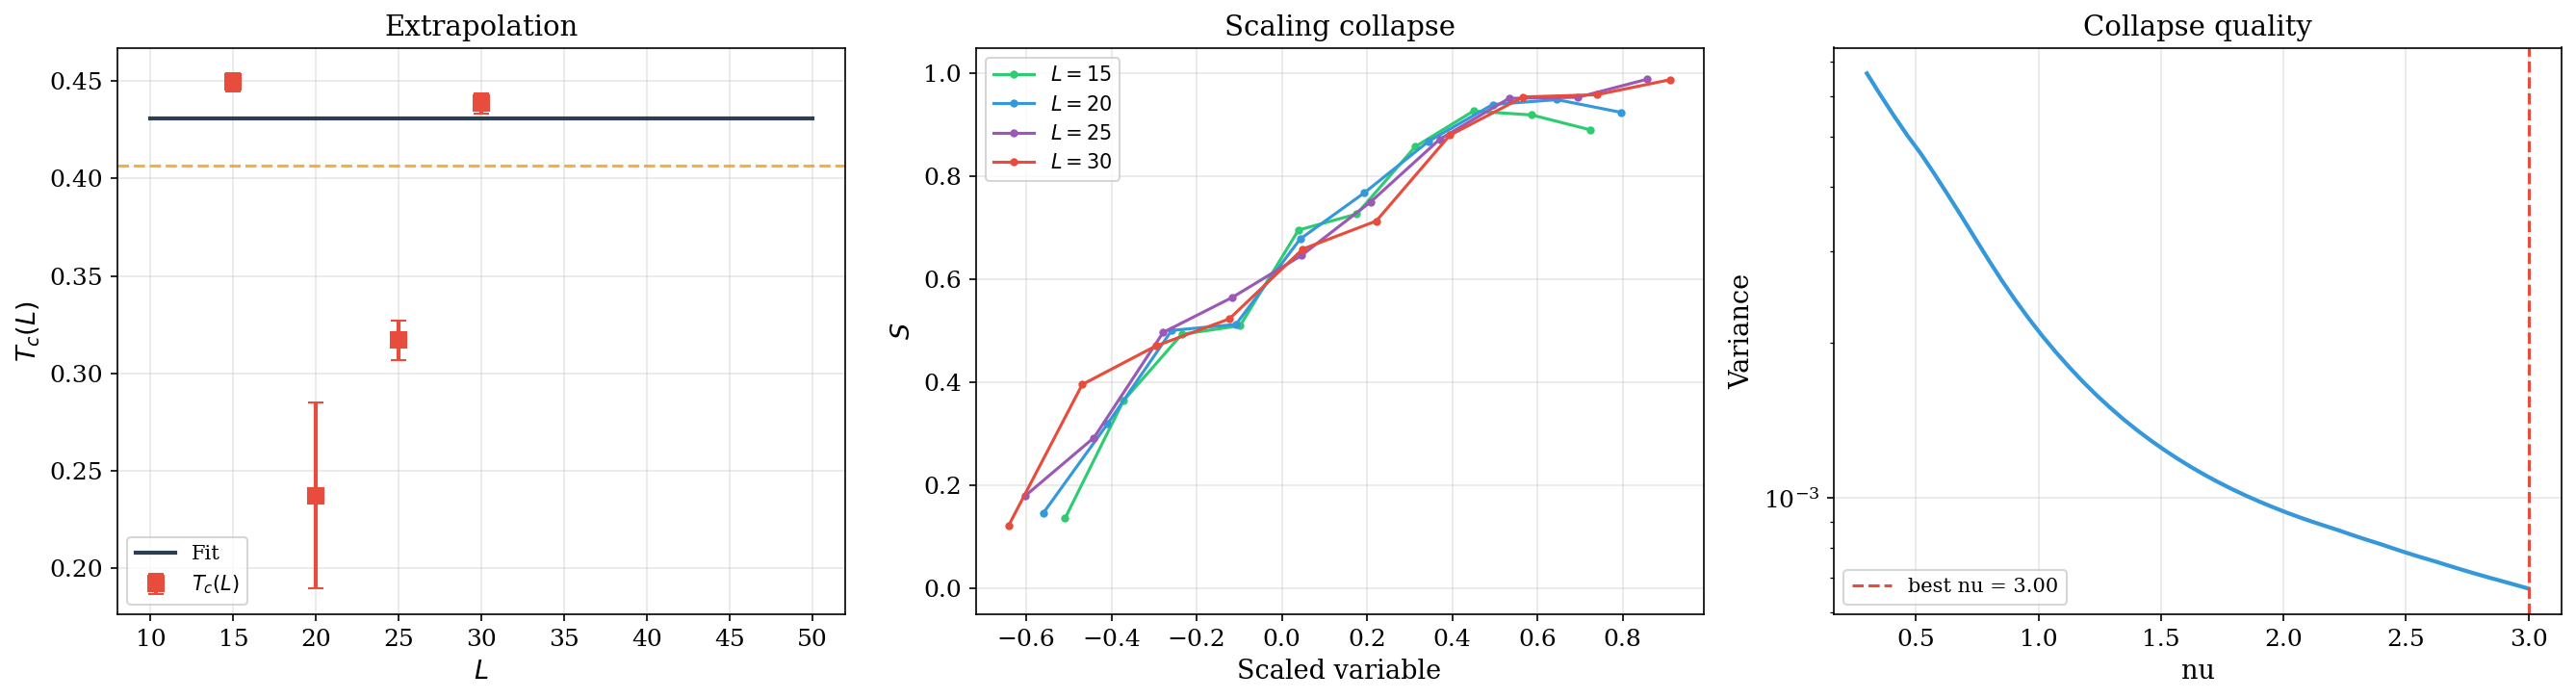

In [5]:
# Tc(L) vs L avec ajustement + Collapse d'échelle
from scipy.optimize import curve_fit

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 : Tc(L)
ax = axes[0]
ax.errorbar(L_arr, Tc_arr, yerr=Tc_err_arr, fmt='s', color='#e74c3c',
            markersize=8, capsize=4, linewidth=2, label='$T_c(L)$')

def _tc_model(L, Tc_inf, a, inv_nu):
    return Tc_inf + a * L ** (-inv_nu)

try:
    popt, _ = curve_fit(_tc_model, L_arr, Tc_arr,
                        p0=[ce['T_c_inf'], 0.5, 1.0/ce['nu'] if ce['nu'] > 0 else 1.0],
                        sigma=Tc_err_arr, absolute_sigma=True, maxfev=10000)
    L_fine = np.linspace(10, 50, 200)
    ax.plot(L_fine, _tc_model(L_fine, *popt), '-', color='#2c3e50', linewidth=2,
            label=f'Fit')
except Exception:
    pass

ax.axhline(ce['T_c_inf'], color='#f39c12', linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_xlabel('$L$')
ax.set_ylabel('$T_c(L)$')
ax.set_title('Extrapolation')
ax.legend()

# Panel 2 : Scaling collapse
sc = scaling_collapse(sizes, tolerance_range, fss['segregation'], ce['T_c_inf'])
print(f"Best collapse nu = {sc['best_nu']:.2f}")

ax = axes[1]
for sz in sizes:
    color = SIZE_COLORS[sz]
    ax.plot(sc['collapsed_x'][sz], sc['collapsed_y'][sz], 'o-', color=color,
            markersize=3, linewidth=1.5, label=f'$L={sz}$')
ax.set_xlabel('Scaled variable')
ax.set_ylabel('$S$')
ax.set_title('Scaling collapse')
ax.legend()
ax.set_ylim(-0.05, 1.05)

# Panel 3 : Quality metric
ax = axes[2]
ax.plot(sc['nu_range'], sc['quality'], '-', color='#3498db', linewidth=2)
ax.axvline(sc['best_nu'], color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'best nu = {sc["best_nu"]:.2f}')
ax.set_xlabel('nu')
ax.set_ylabel('Variance')
ax.set_title('Collapse quality')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 5. Diagramme de phase $(T, \rho)$

Carte de chaleur 2D de l'indice de ségrégation dans l'espace (tolérance, densité), avec contours de la frontière de phase.

Diagramme de phase:   0%|          | 0/8 [00:00<?, ?it/s]

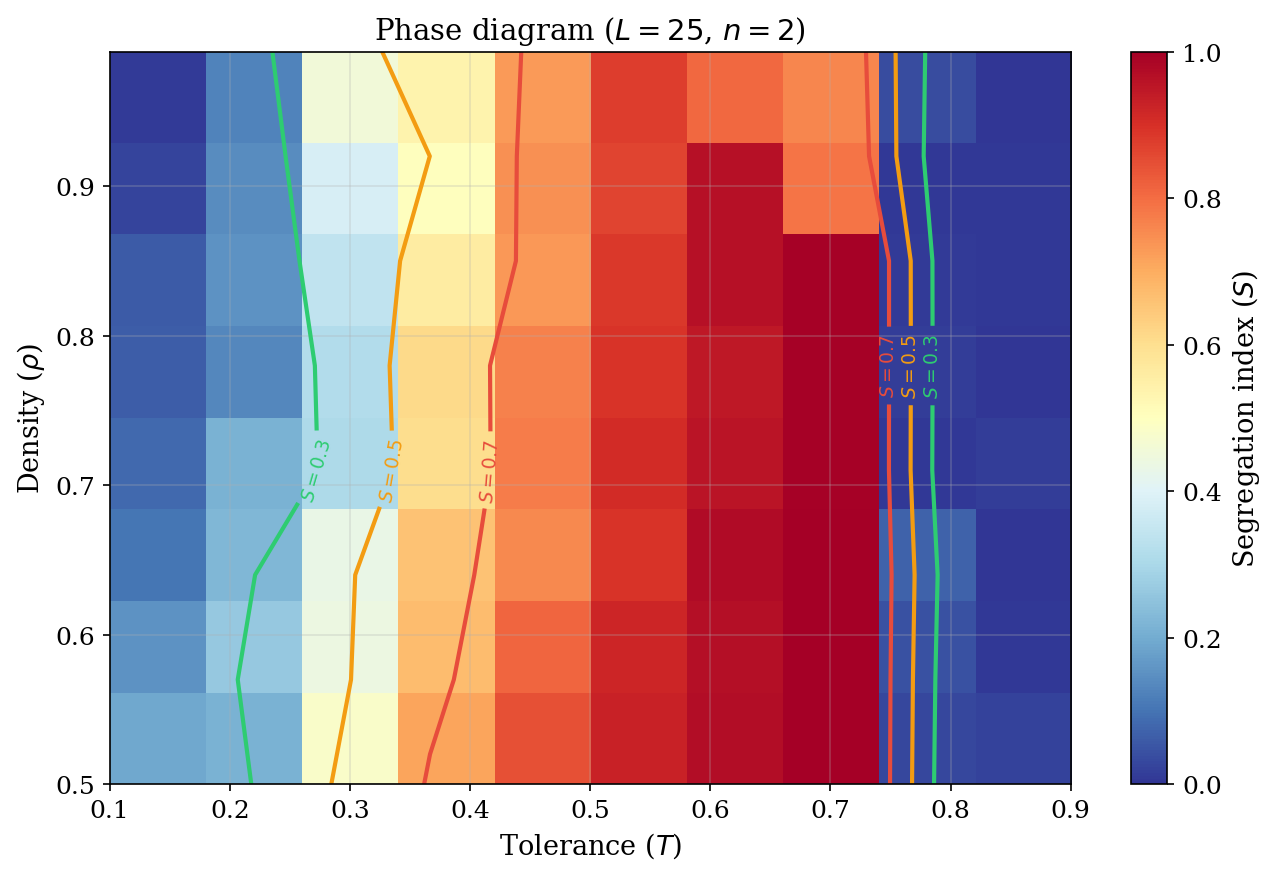

In [6]:
# Diagramme de phase 2D
tols_2d = np.linspace(0.1, 0.9, 10)
dens_2d = np.linspace(0.5, 0.99, 8)
seg_map = np.zeros((len(dens_2d), len(tols_2d)))
rng_pd = np.random.default_rng(0)

for i, rho in enumerate(tqdm(dens_2d, desc='Diagramme de phase')):
    for j, tol in enumerate(tols_2d):
        vals = []
        for _ in range(2):
            seed = rng_pd.integers(0, 2**31)
            model = SchellingModel(size=25, density=rho, tolerance=tol, seed=seed)
            model.run(max_steps=500)
            vals.append(segregation_index(model.grid))
        seg_map[i, j] = np.mean(vals)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(seg_map, cmap='RdYlBu_r', vmin=0.0, vmax=1.0,
               origin='lower', aspect='auto',
               extent=[tols_2d[0], tols_2d[-1], dens_2d[0], dens_2d[-1]])
cs = ax.contour(tols_2d, dens_2d, seg_map, levels=[0.3, 0.5, 0.7],
                colors=['#2ecc71', '#f39c12', '#e74c3c'], linewidths=2)
ax.clabel(cs, fmt='$S=%.1f$', fontsize=9)
ax.set_xlabel('Tolerance ($T$)')
ax.set_ylabel('Density ($\\rho$)')
ax.set_title('Phase diagram ($L=25$, $n=2$)')
plt.colorbar(im, ax=ax, label='Segregation index ($S$)')
plt.tight_layout()
plt.show()

## 6. Trajectoires multi-échelles systématiques

Trajectoires $D(r)$ pour 8 valeurs de tolérance, comparées au modèle nul (grilles aléatoires).

Trajectory sweep...


Null model trajectory...


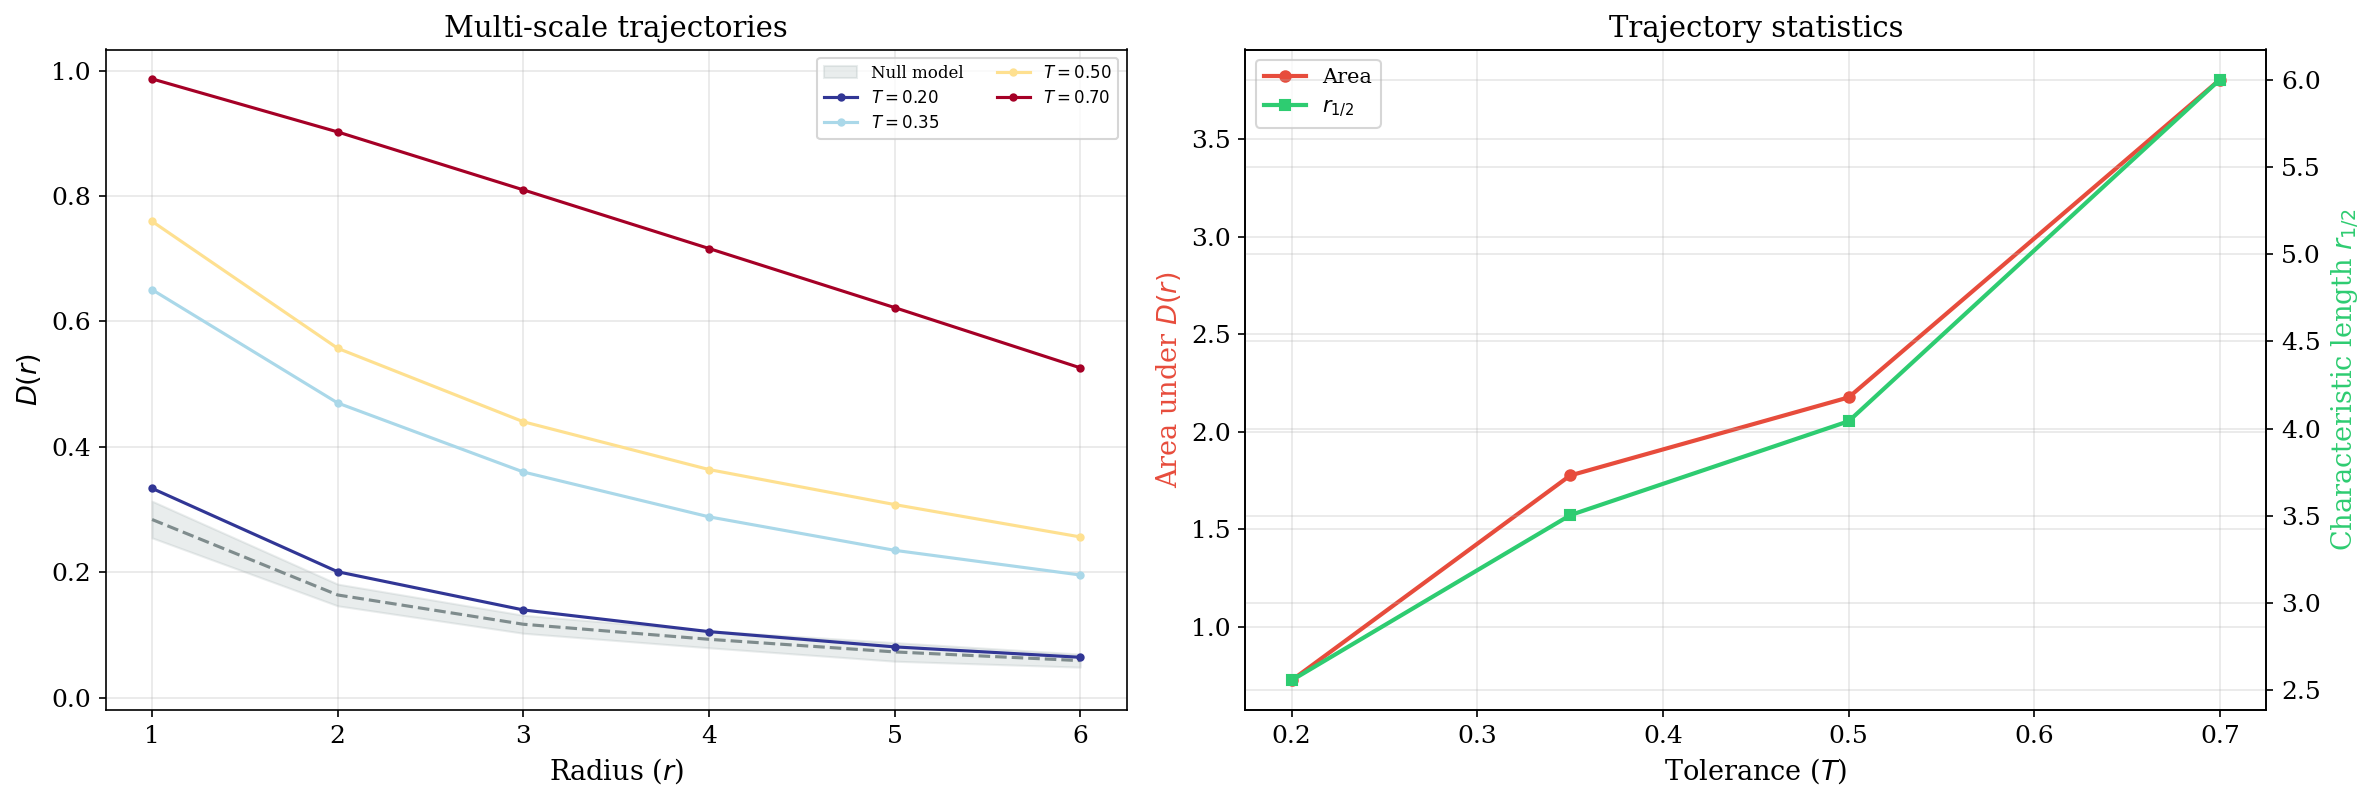


     T     Aire    Pente    r_1/2  D_local D_global
--------------------------------------------------
  0.20    0.727   -0.913     2.56    0.334    0.065
  0.35    1.777   -0.672     3.50    0.651    0.196
  0.50    2.177   -0.647     4.04    0.760    0.256
  0.70    3.807   -0.333     6.00    0.987    0.526


In [7]:
# Trajectoires multi-échelles
traj_tolerances = np.array([0.20, 0.35, 0.50, 0.70])

print("Trajectory sweep...")
sweep = systematic_trajectory_sweep(
    traj_tolerances, size=25, density=0.9, n_trials=3, max_steps=500, seed=0,
)

print("Null model trajectory...")
radii_null, mean_null, std_null = null_model_trajectory(
    size=25, density=0.9, n_samples=5, max_radius=6, seed=99,
)

# Figure
cmap = plt.cm.RdYlBu_r
norm = plt.Normalize(traj_tolerances.min(), traj_tolerances.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

ax1.fill_between(radii_null, mean_null - 2*std_null, mean_null + 2*std_null,
                  alpha=0.2, color='#95a5a6', label='Null model')
ax1.plot(radii_null, mean_null, '--', color='#7f8c8d', linewidth=1.5)

for tol in traj_tolerances:
    color = cmap(norm(tol))
    mean_D, std_D = sweep['trajectories'][tol]
    r = sweep['radii'][:len(mean_D)]
    ax1.plot(r, mean_D, 'o-', color=color, markersize=3, linewidth=1.5,
             label=f'$T = {tol:.2f}$')

ax1.set_xlabel('Radius ($r$)')
ax1.set_ylabel('$D(r)$')
ax1.set_title('Multi-scale trajectories')
ax1.legend(loc='upper right', ncol=2, fontsize=8)
ax1.set_ylim(bottom=-0.02)

areas = [sweep['statistics'][tol]['area'] for tol in traj_tolerances]
char_lengths = [sweep['statistics'][tol]['characteristic_length'] for tol in traj_tolerances]

ax2.plot(traj_tolerances, areas, 'o-', color='#e74c3c', linewidth=2, markersize=5, label='Area')
ax2_twin = ax2.twinx()
ax2_twin.plot(traj_tolerances, char_lengths, 's-', color='#2ecc71', linewidth=2, markersize=5, label='$r_{1/2}$')

ax2.set_xlabel('Tolerance ($T$)')
ax2.set_ylabel('Area under $D(r)$', color='#e74c3c')
ax2_twin.set_ylabel('Characteristic length $r_{1/2}$', color='#2ecc71')
ax2.set_title('Trajectory statistics')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"\n{'T':>6s} {'Aire':>8s} {'Pente':>8s} {'r_1/2':>8s} {'D_local':>8s} {'D_global':>8s}")
print('-' * 50)
for tol in traj_tolerances:
    s = sweep['statistics'][tol]
    print(f"{tol:6.2f} {s['area']:8.3f} {s['slope']:8.3f} {s['characteristic_length']:8.2f} "
          f"{s['D_local']:8.3f} {s['D_global']:8.3f}")

## 7. Tolérance hétérogène

Comparaison du modèle homogène au modèle hétérogène avec $T_k \sim \text{Beta}(\kappa\bar{T}, \kappa(1-\bar{T}))$ pour $\kappa \in \{2, 5, 20\}$.

Comparaison homogène/hétérogène...


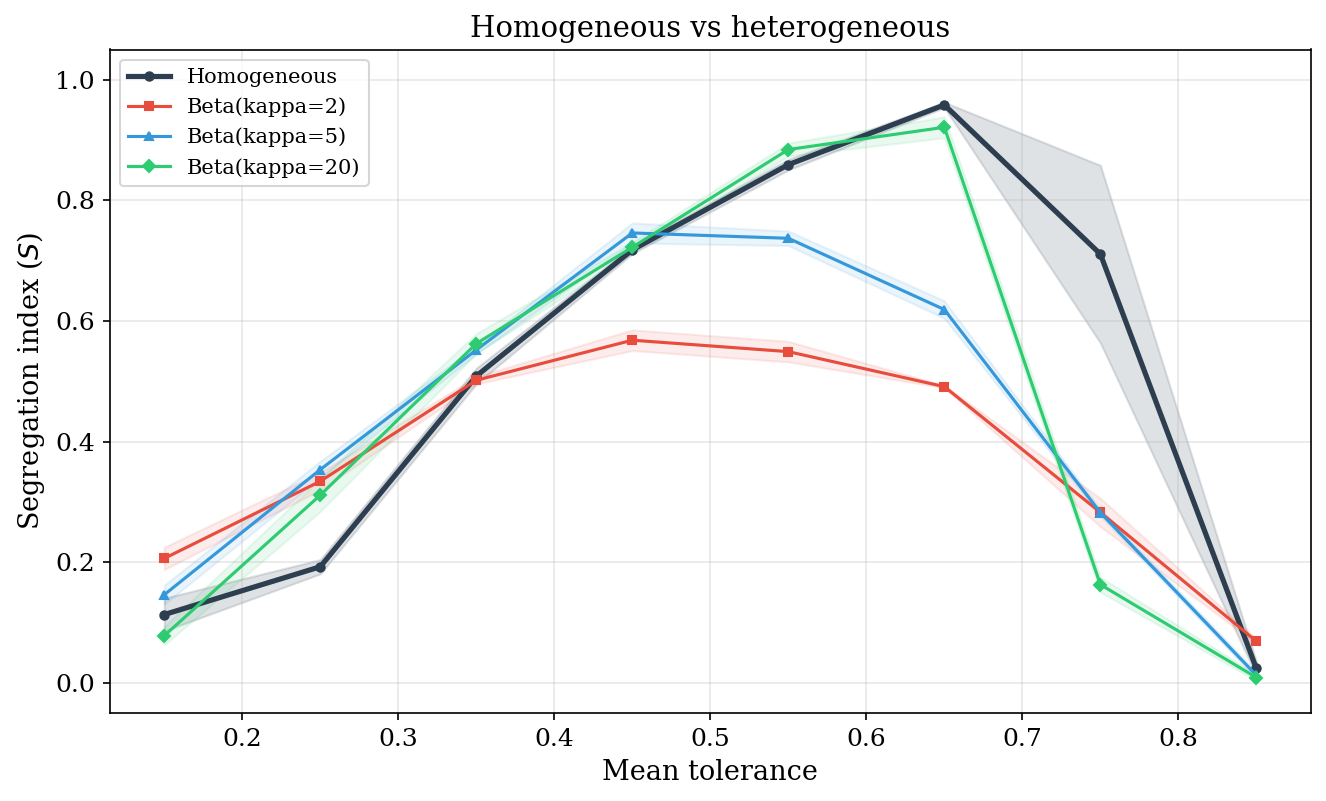


=== Tc per model ===
Homogeneous: Tc = 0.351 +/- 0.006
Beta(kappa= 2.0): Tc = 0.249 +/- 19955.918
Beta(kappa= 5.0): Tc = 0.196 +/- 0.000
Beta(kappa=20.0): Tc = 0.249 +/- 0.000


In [8]:
# Comparaison homogène vs hétérogène
mean_tol_range = np.linspace(0.15, 0.85, 8)
concentrations = [2.0, 5.0, 20.0]

print("Comparaison homogène/hétérogène...")
comp = compare_homogeneous_heterogeneous(
    mean_tol_range, concentrations=concentrations,
    size=25, density=0.9, n_trials=3, max_steps=500, seed=7,
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(mean_tol_range, comp['homogeneous'][0], 'o-', color='#2c3e50', linewidth=2.5,
        markersize=4, label='Homogeneous')
ax.fill_between(mean_tol_range,
                comp['homogeneous'][0] - comp['homogeneous'][1],
                comp['homogeneous'][0] + comp['homogeneous'][1],
                alpha=0.15, color='#2c3e50')

het_colors = {2.0: '#e74c3c', 5.0: '#3498db', 20.0: '#2ecc71'}
het_styles = {2.0: 's-', 5.0: '^-', 20.0: 'D-'}
for kappa in concentrations:
    color = het_colors[kappa]
    mean_seg, std_seg = comp['heterogeneous'][kappa]
    ax.plot(mean_tol_range, mean_seg, het_styles[kappa], color=color,
            linewidth=1.5, markersize=4, label=f'Beta(kappa={kappa:.0f})')
    ax.fill_between(mean_tol_range, mean_seg - std_seg, mean_seg + std_seg,
                     alpha=0.1, color=color)

ax.set_xlabel('Mean tolerance')
ax.set_ylabel('Segregation index ($S$)')
ax.set_title('Homogeneous vs heterogeneous')
ax.legend(loc='upper left')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("\n=== Tc per model ===")
cp_hom = extract_critical_point(mean_tol_range, comp['homogeneous'][0], comp['homogeneous'][1])
print(f"Homogeneous: Tc = {cp_hom['T_c']:.3f} +/- {cp_hom['T_c_err']:.3f}")
for kappa in concentrations:
    mean_seg, std_seg = comp['heterogeneous'][kappa]
    cp_het = extract_critical_point(mean_tol_range, mean_seg, std_seg)
    print(f"Beta(kappa={kappa:4.1f}): Tc = {cp_het['T_c']:.3f} +/- {cp_het['T_c_err']:.3f}")

## 8. Analyse et discussion

### Extraction quantitative de $T_c$

L'ajustement sigmoïdal fournit une estimation précise de $T_c$ avec son intervalle de confiance, là où les études précédentes donnaient une plage qualitative ($T_c \approx 0.35$--$0.40$). La largeur $w$ de la transition diminue avec $L$, confirmant que la transition s'aiguise dans la limite thermodynamique.

### Analyse de taille finie

L'ajustement de $T_c(L) = T_c^\infty + a L^{-1/\nu}$ donne accès au point critique thermodynamique et à l'exposant de longueur de corrélation $\nu$. Le collapse d'échelle valide la cohérence de ces estimations : pour le $\nu$ optimal, les courbes $S$ vs $(T - T_c^\infty) L^{1/\nu}$ se superposent. Ces résultats sont cohérents avec la transition de Gauvin et al. (2009), mais avec des barres d'erreur et des exposants quantitatifs.

### Analyse multi-échelles

Les trajectoires $D(r)$ révèlent des différences structurelles que l'indice $S$ seul ne montre pas. La longueur caractéristique $r_{1/2}$ fournit une mesure directe de la taille typique des amas : elle augmente brusquement autour de $T_c$, puis croît plus lentement à haute tolérance. La comparaison au modèle nul confirme que la ségrégation observée à $T > T_c$ est significativement différente du hasard.

### Tolérance hétérogène

L'extension Beta montre que la dispersion des préférences atténue la ségrégation et déplace $T_c$ vers des valeurs plus élevées. Les agents très tolérants "absorbent" l'insatisfaction locale et empêchent la formation de grands amas. Cela a des implications pour les politiques publiques : une population diverse dans ses préférences devrait produire moins de ségrégation qu'une population homogène, même à tolérance moyenne égale.

### Limites

Le modèle reste simplifié : grille régulière, deux types, pas de contraintes économiques (Clark & Fossett, 2008). Le modèle est hors équilibre, donc l'analogie avec les transitions de phase thermodynamiques est partielle (Dall'Asta et al., 2008). Des extensions avec des fonctions d'utilité (Grauwin et al., 2012) ou des réseaux irréguliers permettraient de se rapprocher de la réalité.